# Solución del laboratorio 3: Zara: pronóstico que alimenta la reposición
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


metricas
            metodo  MAE_validacion  sesgo_validacion  MAE_prueba  sesgo_prueba
           ingenuo       19.000000          1.000000   19.000000      1.000000
       media_movil       13.333333          2.000000   13.333333      2.000000
ingenuo_estacional        4.000000          4.000000    4.000000      4.000000
           ses_0.2       12.629719          5.129127   12.605133      5.052891
           ses_0.5       15.599998          2.000009   15.600000      2.000001
           ses_0.8       18.461538          1.250000   18.461538      1.250000

pronosticos
 periodo  demanda  ingenuo  media_movil  ingenuo_estacional    ses_0.2    ses_0.5    ses_0.8
       1     80.0      NaN          NaN                 NaN  80.000000  80.000000  80.000000
       2    100.0     80.0          NaN                 NaN  80.000000  80.000000  80.000000
       3    120.0    100.0          NaN                 NaN  84.000000  90.000000  96.000000
       4    100.0    120.0   100.000000             

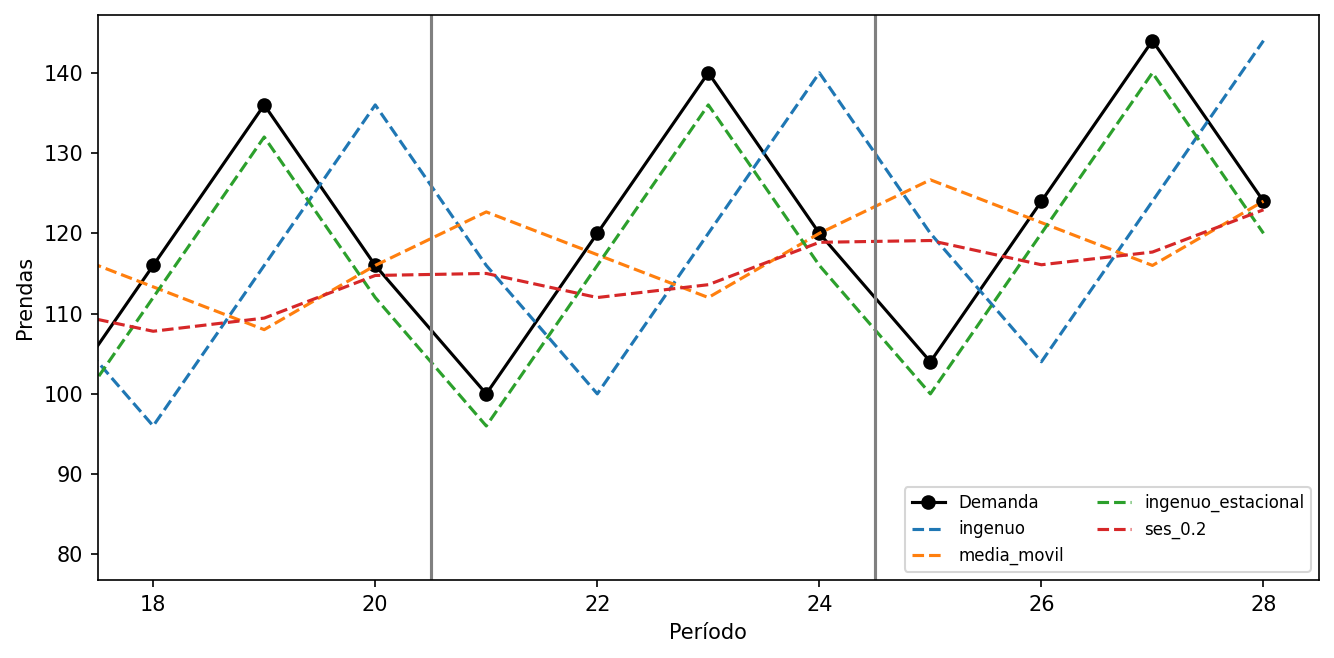

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

ajuste=pd.read_csv(datos / "ajuste.csv")
validacion=pd.read_csv(datos / "validacion.csv")
m=parametros["estacionalidad"]
w=parametros["ventana_media_movil"]

def pronosticos(y):
    y=np.asarray(y,dtype=float)
    ingenuo=np.r_[np.nan,y[:-1]]
    mm=np.full(len(y),np.nan); ie=mm.copy()
    for t in range(w,len(y)):
        mm[t]=np.mean(y[t-w:t])
    for t in range(m,len(y)):
        ie[t]=y[t-m]
    f={"ingenuo":ingenuo,"media_movil":mm,"ingenuo_estacional":ie}
    for alpha in parametros["alphas"]:
        ses=np.empty(len(y)); ses[0]=y[0]
        for t in range(1,len(y)):
            ses[t]=alpha*y[t-1]+(1-alpha)*ses[t-1]
        f[f"ses_{alpha:g}"]=ses
    return f

def metricas(y,f,indices):
    e=y[indices]-f[indices]
    return float(np.mean(np.abs(e))),float(np.mean(e))

# Selección cerrada antes de leer la prueba final.
pasado=pd.concat([ajuste,validacion],ignore_index=True)
y=pasado.demanda_unidades.to_numpy(float)
iv=np.arange(len(ajuste),len(pasado))
f=pronosticos(y)
alpha=min(parametros["alphas"],key=lambda a:(metricas(y,f[f"ses_{a:g}"],iv)[0],a))
candidatos=["ingenuo","media_movil","ingenuo_estacional",f"ses_{alpha:g}"]
seleccionado=min(candidatos,key=lambda nombre:
                 (metricas(y,f[nombre],iv)[0],candidatos.index(nombre)))
seleccion={"alpha_ses":alpha,"metodo":seleccionado,
           "ultimo_periodo_seleccion":int(pasado.periodo.max())}
(salida / "seleccion_validacion.json").write_text(json.dumps(seleccion,indent=2))

# Ahora se habilita la prueba. Los bucles solo utilizan y anteriores a t.
prueba=pd.read_csv(datos / "prueba_final.csv")
df=pd.concat([pasado,prueba],ignore_index=True)
assert df.periodo.tolist()==list(range(1,29))
y=df.demanda_unidades.to_numpy(float); f=pronosticos(y)
it=np.arange(len(pasado),len(df))
filas=[]
for nombre,pred in f.items():
    a,b=metricas(y,pred,iv); c,d=metricas(y,pred,it)
    filas.append({"metodo":nombre,"MAE_validacion":a,"sesgo_validacion":b,
                  "MAE_prueba":c,"sesgo_prueba":d})
tabla(pd.DataFrame(filas),"metricas")
tabla(pd.DataFrame({"periodo":df.periodo,"demanda":y,**f}),"pronosticos")
fig,ax=plt.subplots(figsize=(9,4.5))
ax.plot(df.periodo,y,"o-",label="Demanda",color="black")
for nombre in candidatos:
    ax.plot(df.periodo,f[nombre],"--",label=nombre)
ax.axvline(20.5,color="gray"); ax.axvline(24.5,color="gray")
ax.set(xlabel="Período",ylabel="Prendas",xlim=(17.5,28.5))
ax.legend(fontsize=8,ncol=2)
figura(fig,"pronosticos")
assert seleccionado=="ingenuo_estacional"
assert metricas(y,f[seleccionado],it)==(4.0,4.0)
# Perturbar solo el futuro no cambia pronósticos previos.
y_alt=y.copy(); y_alt[25:]+=500
f_alt=pronosticos(y_alt)
for nombre in f:
    assert np.allclose(f[nombre][:26],f_alt[nombre][:26],equal_nan=True)
resumen({**seleccion,"metricas":filas})
